# Exploring the Data Generation Process Using Python and Pandas

## 📚 Learning Objectives

By completing this notebook, you will:
- Explore the **data-generating process** behind a real dataset
- Use Python and Pandas to read and profile real data
- Understand real data distributions — skew, bounds and missingness
- See why real columns rarely look like the tidy bell curves in textbooks
- Apply this profiling habit to ML scenarios

## 🔗 Prerequisites

- ✅ Understanding of data science
- ✅ Pandas knowledge
- ✅ NumPy knowledge

---

This notebook covers practical activities from **Course 01, Unit 2**:
- Exploring the data generation process using Python and Pandas

---

## Introduction

Every dataset is the fingerprint of a **real process in the world**. Somebody decided what
to record, somebody wrote it down, and some records went missing. That chain of events is
the **data-generating process (DGP)**.

We explore it here on the **Titanic passenger manifest** — 891 real passengers from the
1912 voyage, with the ticket class, fare, age and survival outcome that clerks actually
recorded. Reading the distributions tells you what the process was really like, and the
gaps tell you where the process broke down.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Load a REAL dataset and let the data-generating process speak for itself.
# The Titanic manifest was produced by clerks in 1912: what they recorded, how they
# recorded it, and what they failed to record are all visible in the columns below.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported!")
print("\nExploring the Data Generation Process")
print("=" * 60)

# Read the real CSV shipped with this diploma (no internet required).
df = pd.read_csv("../../../Course 04/datasets/raw/titanic.csv")

print("\nReal dataset (Titanic passenger manifest, 1912):")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")

print("\n✅ Real dataset loaded!")
print("\n💡 Nobody chose these numbers. Every row is a person who bought a ticket.")

✅ Libraries imported!

Exploring the Data Generation Process

Real dataset (Titanic passenger manifest, 1912):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S

In [2]:
# Profile the real distributions. Unlike an invented dataset, nothing here was drawn
# from a neat bell curve — so describe() shows us what the WORLD produced, including
# hard bounds, heavy skew and outliers we did not put there on purpose.
print("=" * 60)
print("REAL DATA DISTRIBUTIONS")
print("=" * 60)

numeric_cols = ["Age", "Fare", "SibSp", "Parch"]
print("\nStatistical Summary:")
print(df[numeric_cols].describe())

# Skewness measures asymmetry: 0 = symmetric bell curve, large positive = long right tail.
print("\n\nSkewness of each numeric column (0 would mean a symmetric bell curve):")
for col in numeric_cols:
    print(f"  {col:6s}: {df[col].skew():+.2f}")

print("\n\nCategorical Distributions (real, and far from balanced):")
for col in ["Pclass", "Sex", "Embarked"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

print("\n✅ Data exploration completed!")

REAL DATA DISTRIBUTIONS

Statistical Summary:
              Age        Fare       SibSp       Parch
count  714.000000  891.000000  891.000000  891.000000
mean    29.699118   32.204208    0.523008    0.381594
std     14.526497   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     20.125000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     38.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000


Skewness of each numeric column (0 would mean a symmetric bell curve):
  Age   : +0.39
  Fare  : +4.79
  SibSp : +3.70
  Parch : +2.75


Categorical Distributions (real, and far from balanced):

Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

✅ Data exploration completed!


### 🔎 Where the process broke down: real missing values

An invented dataset is complete by construction. A real one is not. Missingness is
**part of the data-generating process** — it tells you which facts the clerks could not
or did not record, and that pattern is itself information.

In [3]:
# Count the real gaps. These are not simulated holes — they are facts that were never
# written down in 1912, and every ML pipeline you build later must decide what to do with them.
print("=" * 60)
print("MISSINGNESS: THE PART OF THE PROCESS THAT FAILED")
print("=" * 60)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nColumns with missing values:")
for col, n in missing.items():
    print(f"  {col:10s}: {n:4d} missing ({n / len(df) * 100:5.1f}% of rows)")

print("\n💡 The Cabin column is mostly empty because cabin numbers were mainly recorded")
print("   for higher-paying passengers. The missingness itself carries class information —")
print("   which is exactly why you must never delete it without thinking.")

# Evidence for that claim, straight from the data:
cabin_known_by_class = df.assign(cabin_known=df["Cabin"].notna()).groupby("Pclass")["cabin_known"].mean()
print("\nProportion of passengers with a recorded cabin, by ticket class:")
for pclass, frac in cabin_known_by_class.items():
    print(f"  Class {pclass}: {frac * 100:5.1f}%")

MISSINGNESS: THE PART OF THE PROCESS THAT FAILED

Columns with missing values:
  Cabin     :  687 missing ( 77.1% of rows)
  Age       :  177 missing ( 19.9% of rows)
  Embarked  :    2 missing (  0.2% of rows)

💡 The Cabin column is mostly empty because cabin numbers were mainly recorded
   for higher-paying passengers. The missingness itself carries class information —
   which is exactly why you must never delete it without thinking.

Proportion of passengers with a recorded cabin, by ticket class:
  Class 1:  81.5%
  Class 2:   8.7%
  Class 3:   2.4%


### 📊 Seeing the shape of a real process

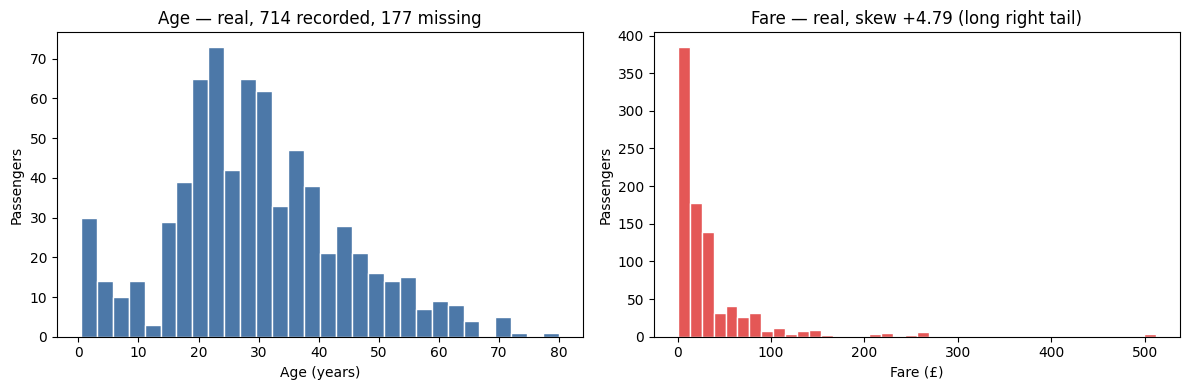

Cheapest ticket: £0.00    Median: £14.45    Most expensive: £512.33

💡 Median and maximum are far apart. That gap is what a real, unequal process
   looks like — and it is the reason the MEAN fare would mislead you here.


In [4]:
# Plot the two most informative numeric columns. Compare the shapes: Age is roughly
# bell-like but truncated at 0 and dented by the missing values; Fare is violently
# right-skewed because a handful of passengers paid enormous sums.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Age"].dropna(), bins=30, color="#4C78A8", edgecolor="white")
axes[0].set_title(f"Age — real, {df['Age'].notna().sum()} recorded, {df['Age'].isna().sum()} missing")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Passengers")

axes[1].hist(df["Fare"], bins=40, color="#E45756", edgecolor="white")
axes[1].set_title(f"Fare — real, skew {df['Fare'].skew():+.2f} (long right tail)")
axes[1].set_xlabel("Fare (£)")
axes[1].set_ylabel("Passengers")

plt.tight_layout()
plt.show()

print(f"Cheapest ticket: £{df['Fare'].min():.2f}    Median: £{df['Fare'].median():.2f}    "
      f"Most expensive: £{df['Fare'].max():.2f}")
print("\n💡 Median and maximum are far apart. That gap is what a real, unequal process")
print("   looks like — and it is the reason the MEAN fare would mislead you here.")

## Summary

This notebook covered:
- ✅ **The data-generating process**: reading a real dataset as the fingerprint of a real event
- ✅ **Data Exploration**: real distributions, skew, and hard bounds
- ✅ **Missingness**: gaps that are themselves information, not noise to be deleted
- ✅ **Data Types**: working with real numerical and categorical columns

**The honest takeaway:** real columns are skewed, bounded, imbalanced and incomplete.
An invented dataset drawn from tidy normal curves would have hidden every one of those
lessons — and the habits you build on tidy data break the first time you meet a real CSV.

## 📚 References

1. Box, G. E. P., & Muller, M. E. (1958). *A Note on the Generation of Random Normal Deviates*. Annals of Mathematical Statistics, 29(2), 610–611.
2. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array programming with NumPy*. Nature, 585, 357–362. <https://arxiv.org/abs/2006.10256>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 2: Statistical Learning. Springer.